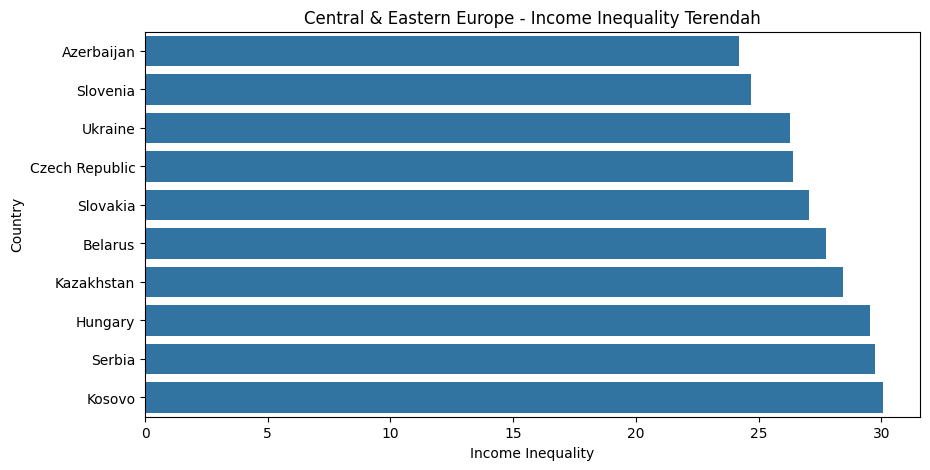

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data (perhatikan sep=';')
df = pd.read_csv("Kelas D_Happiness and Satisfaction.csv", sep=';')

# Konversi semua angka yang masih pakai koma menjadi titik
def fix_decimal(x):
    if isinstance(x, str):
        return x.replace(',', '.')
    return x

for col in df.columns:
    df[col] = df[col].apply(fix_decimal)

# ubah kolom numerik ke float (yang relevan saja)
num_cols = [
    'adjusted_satisfaction (0-100)',
    'avg_satisfaction (0-10)',
    'std_satisfaction',
    'avg_income (&)',
    'median_income (&)',
    'income_inequality',
    'Happy Score (0-10)',
    'GDP'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

cee = df[df['Region'].str.contains("Central and Eastern Europe")]

cee_sorted = cee.sort_values('income_inequality').head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    data=cee_sorted,
    x='income_inequality',
    y='Country'
)

plt.title("Central & Eastern Europe - Income Inequality Terendah")
plt.xlabel("Income Inequality")
plt.ylabel("Country")
plt.show()